# Task

đọc data
data minning
Data visualization (trend, mùa, tương quan, chuỗi,...)
Tính dừng, ACF, PACF
ARIMA, SARIMA,
fit arima, fit sarima
So sánh
ARCH/GARCH
Fit ARCH, fit GARCH
Dự báo volatility
smoothing average
STL Forecast
Chọn mô hình tốt nhất trong các mô hình khi phân tích dữ liệu theo Time Series Model
Conclusion

Here is all the data you need:
"HstQtcbInterestRate_20130130_20180129 (1).csv"

## Data loading

### Subtask:
Load the interest rate data from the provided CSV file.


In [2]:
import pandas as pd

# Load the CSV file into a pandas DataFrame.
df = pd.read_csv('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/TREASURY STATMENT/HstQtcbInterestRate_20130130_20180129.csv', dayfirst=True)

# Display the first few rows of the DataFrame and check data types.
display(df.head())
print(df.dtypes)

,Record Date,Interest Rate Percent,Maturity Description,Permitted Sinking Fund Yield Percent,Source Line Number,Fiscal Year,Fiscal Quarter Number,Calendar Year,Calendar Quarter Number,Calendar Month Number,Calendar Day Number
0,2018-01-29,4.12,34 years,2.1,1,2018,2,2018,1,1,29
1,2018-01-26,4.10,34 years,2.1,1,2018,2,2018,1,1,26
2,2018-01-25,4.14,34 years,2.1,1,2018,2,2018,1,1,25
3,2018-01-24,4.11,34 years,2.1,1,2018,2,2018,1,1,24
4,2018-01-23,4.14,34 years,2.1,1,2018,2,2018,1,1,23


Record Date                              object
Interest Rate Percent                   float64
Maturity Description                     object
Permitted Sinking Fund Yield Percent    float64
Source Line Number                        int64
Fiscal Year                               int64
Fiscal Quarter Number                     int64
Calendar Year                             int64
Calendar Quarter Number                   int64
Calendar Month Number                     int64
Calendar Day Number                       int64
dtype: object


## Data exploration

### Subtask:
Explore the interest rate data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

import ace_tools_open as tools
tools.display_dataframe_to_user("Preview of HstQtcbInterestRate.csv", df.head(10))
print("Columns:", df.columns.tolist())
print(df.dtypes)

# 2. Identify and parse date column
# Try common date column names
date_col = None
for col in df.columns:
    lower = col.lower()
    if 'date' in lower or 'time' in lower:
        date_col = col
        break
# If not found, check first column if likely date
if date_col is None:
    date_col = df.columns[0]
print(f"Using date column: {date_col}")
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])
df = df.sort_values(by=date_col)

Preview of HstQtcbInterestRate.csv


Loading ITables v2.4.2 from the internet... (need help?)


Columns: ['Record Date', 'Interest Rate Percent', 'Maturity Description', 'Permitted Sinking Fund Yield Percent', 'Source Line Number', 'Fiscal Year', 'Fiscal Quarter Number', 'Calendar Year', 'Calendar Quarter Number', 'Calendar Month Number', 'Calendar Day Number']
Record Date                             datetime64[ns]
Interest Rate Percent                          float64
Maturity Description                            object
Permitted Sinking Fund Yield Percent           float64
Source Line Number                               int64
Fiscal Year                                      int64
Fiscal Quarter Number                            int64
Calendar Year                                    int64
Calendar Quarter Number                          int64
Calendar Month Number                            int64
Calendar Day Number                              int64
dtype: object
Using date column: Record Date


In [10]:
# 3. Identify value columns (numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
# If multiple numeric columns, choose one or pivot later. Here assume one series: first numeric.
if not numeric_cols:
    raise ValueError("No numeric columns found for time series value.")
value_col = numeric_cols[0]
print(f"Using value column: {value_col}")

Numeric columns: ['Interest Rate Percent', 'Permitted Sinking Fund Yield Percent', 'Source Line Number', 'Fiscal Year', 'Fiscal Quarter Number', 'Calendar Year', 'Calendar Quarter Number', 'Calendar Month Number', 'Calendar Day Number']
Using value column: Interest Rate Percent


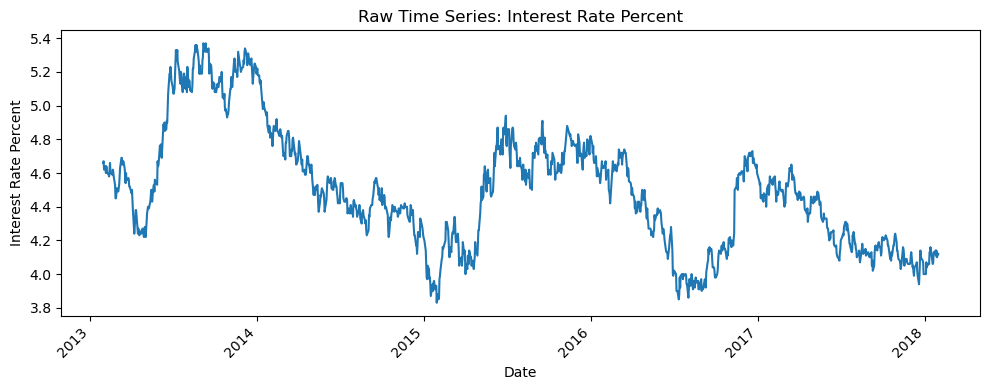

In [11]:
# 4. Create time series
ts = df.set_index(date_col)[value_col]
# Check frequency - plot raw
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values)
plt.title(f"Raw Time Series: {value_col}")
plt.xlabel("Date"); plt.ylabel(value_col)
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.show()

Resampled monthly series (head)


Loading ITables v2.4.2 from the internet... (need help?)


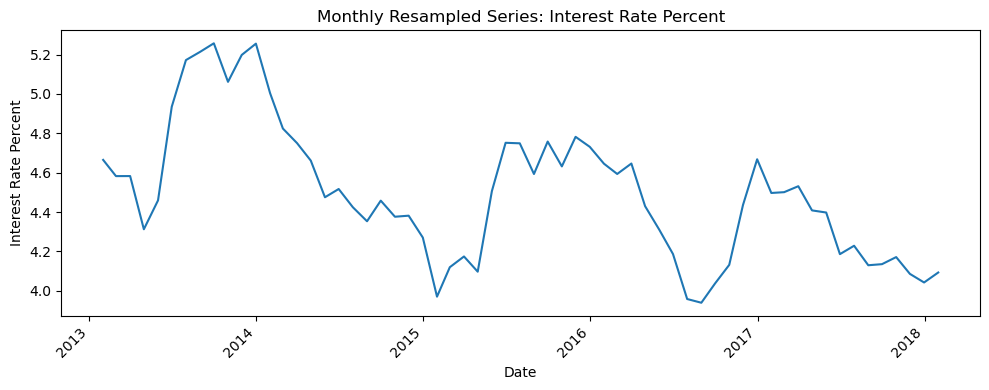

In [12]:
# 5. Resample to regular frequency if needed (e.g., monthly)
# Try to infer frequency; if irregular, resample monthly by mean
ts_monthly = ts.resample('M').mean().interpolate(method='linear')
tools.display_dataframe_to_user("Resampled monthly series (head)", ts_monthly.head(12))

plt.figure(figsize=(10,4))
plt.plot(ts_monthly.index, ts_monthly.values)
plt.title(f"Monthly Resampled Series: {value_col}")
plt.xlabel("Date"); plt.ylabel(value_col)
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.show()

In [13]:
# 6. ADF test on monthly series
adf_res = adfuller(ts_monthly.dropna())
print("ADF Statistic: %.4f, p-value: %.4f" % (adf_res[0], adf_res[1]))
for key, val in adf_res[4].items():
    print(f"Critical Value {key}: {val:.4f}")

ADF Statistic: -2.4052, p-value: 0.1403
Critical Value 1%: -3.5507
Critical Value 5%: -2.9138
Critical Value 10%: -2.5946


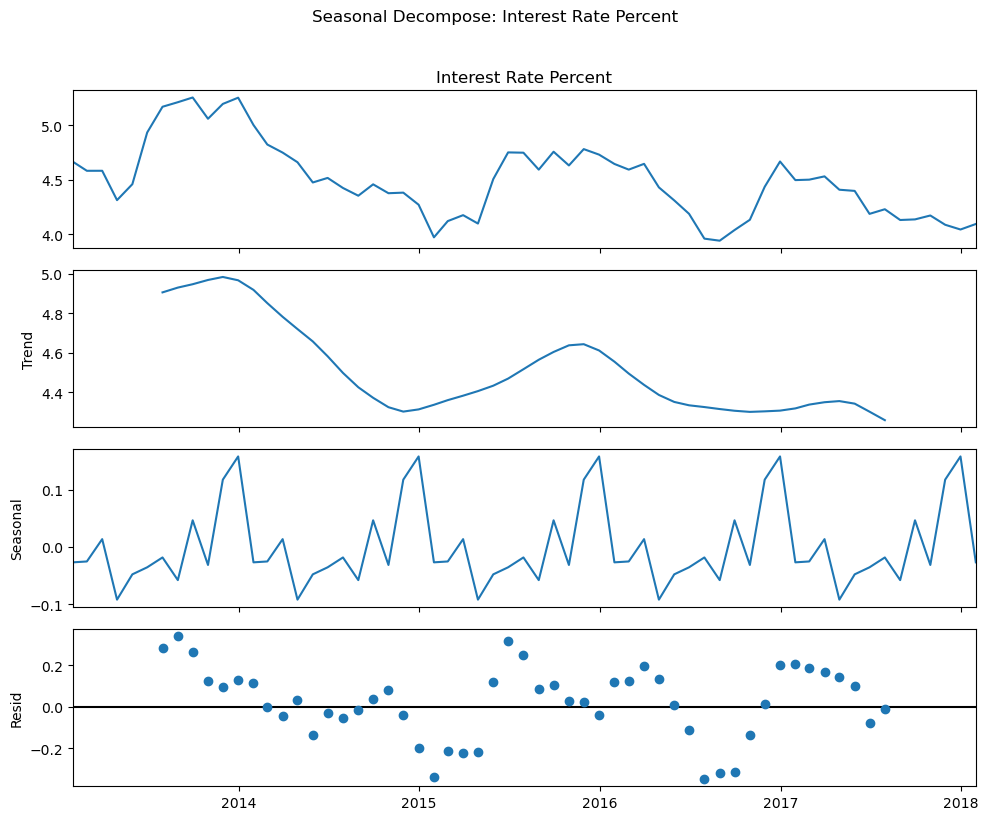

In [14]:
# 7. Seasonal decomposition if length >=24
if len(ts_monthly.dropna()) >= 24:
    try:
        decomp = seasonal_decompose(ts_monthly.dropna(), model='additive', period=12)
        fig = decomp.plot()
        fig.set_size_inches(10, 8)
        plt.suptitle(f"Seasonal Decompose: {value_col}", y=1.02)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Decomposition error:", e)

<Figure size 1000x400 with 0 Axes>

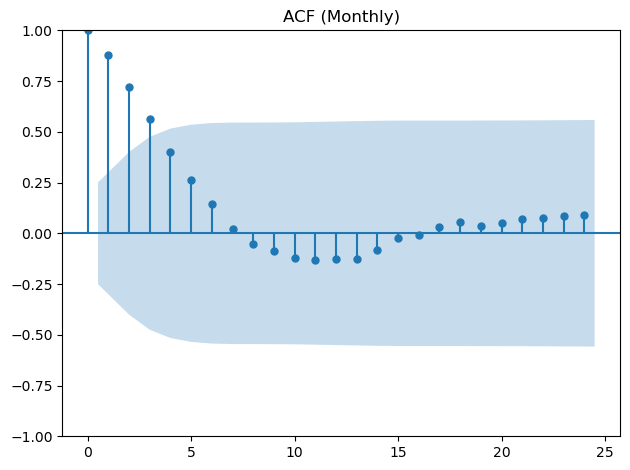

<Figure size 1000x400 with 0 Axes>

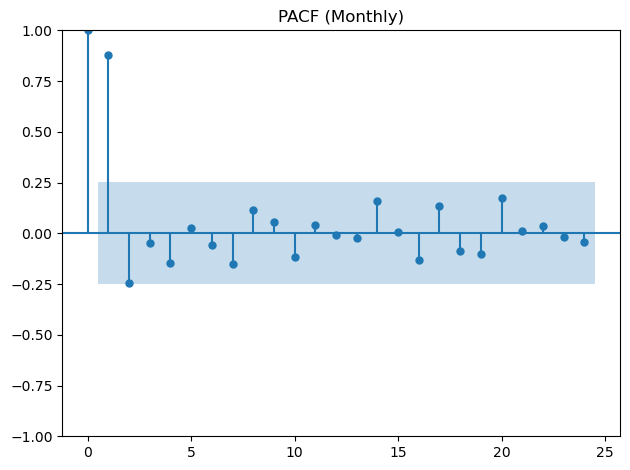

In [15]:
# 8. ACF/PACF plots
plt.figure(figsize=(10,4))
plot_acf(ts_monthly.dropna(), lags=24)
plt.title("ACF (Monthly)"); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,4))
plot_pacf(ts_monthly.dropna(), lags=24, method='ywm')
plt.title("PACF (Monthly)"); plt.tight_layout(); plt.show()

In [16]:
# 9. Grid search ARIMA order
best_aic = np.inf
best_order = None
ts_clean = ts_monthly.dropna()
for p in range(4):
    for d in range(2):
        for q in range(4):
            try:
                res = ARIMA(ts_clean, order=(p,d,q)).fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p,d,q)
            except:
                continue
print(f"Best ARIMA order: {best_order}, AIC={best_aic:.1f}")

Best ARIMA order: (2, 1, 3), AIC=-50.0


Test MAE: 0.2708, RMSE: 0.3190


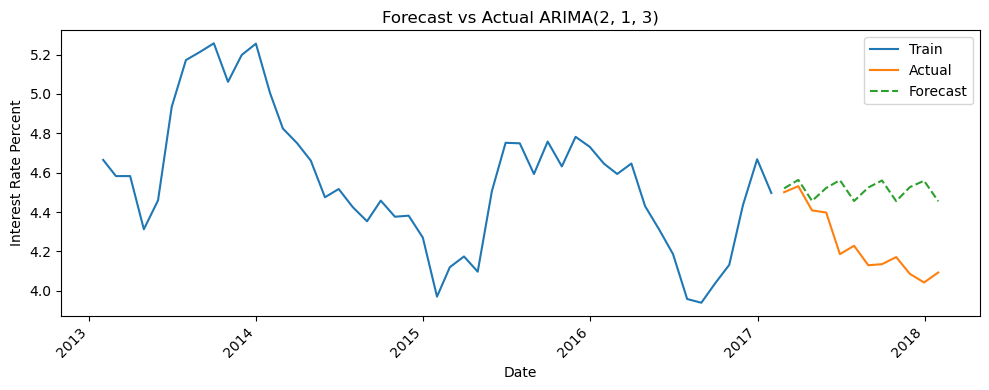

In [18]:
# 10. Train-test split and evaluation
test_periods = 12
if len(ts_clean) > test_periods:
    train = ts_clean.iloc[:-test_periods]
    test = ts_clean.iloc[-test_periods:]
    res_train = ARIMA(train, order=best_order).fit()
    forecast = res_train.forecast(steps=test_periods)
    forecast.index = test.index
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f"Test MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    plt.figure(figsize=(10,4))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Actual')
    plt.plot(forecast.index, forecast, label='Forecast', linestyle='--')
    plt.title(f"Forecast vs Actual ARIMA{best_order}")
    plt.xlabel("Date"); plt.ylabel(value_col)
    plt.legend(); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

Future forecast:
Forecast next periods


Loading ITables v2.4.2 from the internet... (need help?)


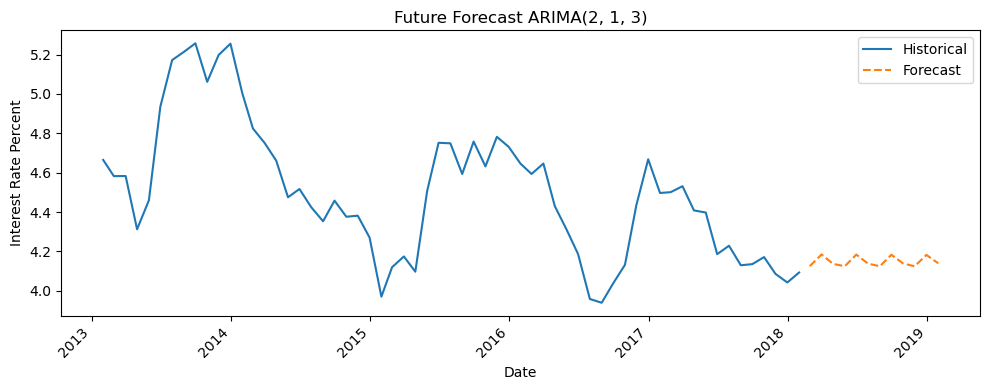

In [17]:
# 11. Fit final ARIMA and future forecast
res_full = ARIMA(ts_clean, order=best_order).fit()
horizon = 12
future = res_full.forecast(steps=horizon)
last_date = ts_clean.index[-1]
future_idx = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=horizon, freq='M')
future.index = future_idx
print("Future forecast:")
tools.display_dataframe_to_user("Forecast next periods", future)
plt.figure(figsize=(10,4))
plt.plot(ts_clean, label='Historical')
plt.plot(future.index, future, label='Forecast', linestyle='--')
plt.title(f"Future Forecast ARIMA{best_order}")
plt.xlabel("Date"); plt.ylabel(value_col)
plt.legend(); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [22]:
# Giả sử ts_monthly là original
ts_log = np.log(ts_monthly)
ts_log_seasonal_diff = ts_monthly.diff(12).dropna()
ts_log_seasonal_then_diff = ts_log_seasonal_diff.diff().dropna()

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Giả sử ts_log là log series và đã differenced inside model
# Grid search ví dụ nhỏ:
best_aic = np.inf
best_order = None
best_seasonal = None
for p in range(3):
    for d in [1]:
        for q in range(3):
            for P in range(2):
                for D in [1]:
                    for Q in range(2):
                        try:
                            model = SARIMAX(ts_log, order=(p,d,q), seasonal_order=(P,D,Q,12), enforce_stationarity=False, enforce_invertibility=False)
                            res = model.fit(disp=False)
                            if res.aic < best_aic:
                                best_aic = res.aic
                                best_order = (p,d,q)
                                best_seasonal = (P,D,Q,12)
                        except:
                            continue
print("Best SARIMA:", best_order, best_seasonal, "AIC:", best_aic)

# Fit final
model = SARIMAX(ts_log, order=best_order, seasonal_order=best_seasonal, enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)
print(res.summary())


Best SARIMA: (1, 1, 0) (0, 1, 0, 12) AIC: -150.8817310886403
                                     SARIMAX Results                                      
Dep. Variable:              Interest Rate Percent   No. Observations:                   61
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                  77.441
Date:                            Mon, 23 Jun 2025   AIC                           -150.882
Time:                                    15:00:17   BIC                           -147.181
Sample:                                01-31-2013   HQIC                          -149.489
                                     - 01-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3385      0.167      2.027      0.04

ADF Test for Original Monthly Series:
  ADF Statistic: -2.4052
  p-value: 0.1403
  Critical Value 1%: -3.5507
  Critical Value 5%: -2.9138
  Critical Value 10%: -2.5946



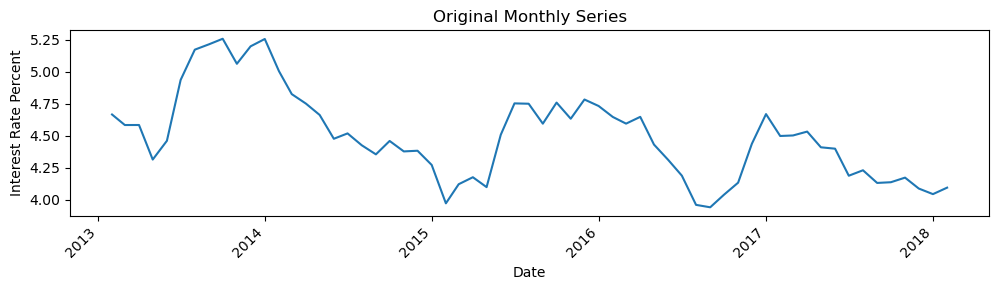

ADF Test for Log Transformed Series:
  ADF Statistic: -2.4532
  p-value: 0.1273
  Critical Value 1%: -3.5507
  Critical Value 5%: -2.9138
  Critical Value 10%: -2.5946



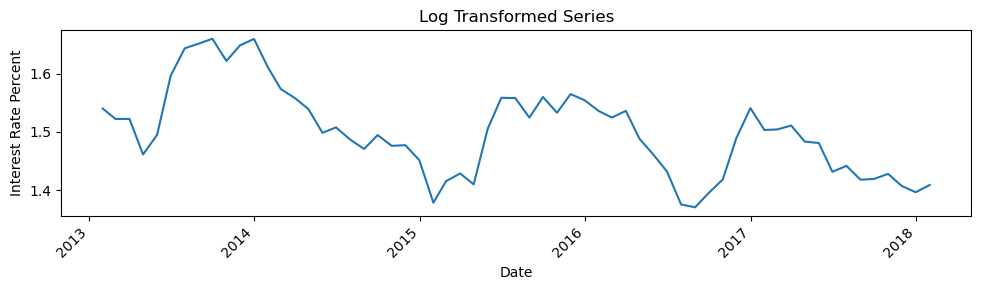

ADF Test for First Difference Series:
  ADF Statistic: -6.2736
  p-value: 0.0000
  Critical Value 1%: -3.5464
  Critical Value 5%: -2.9119
  Critical Value 10%: -2.5937



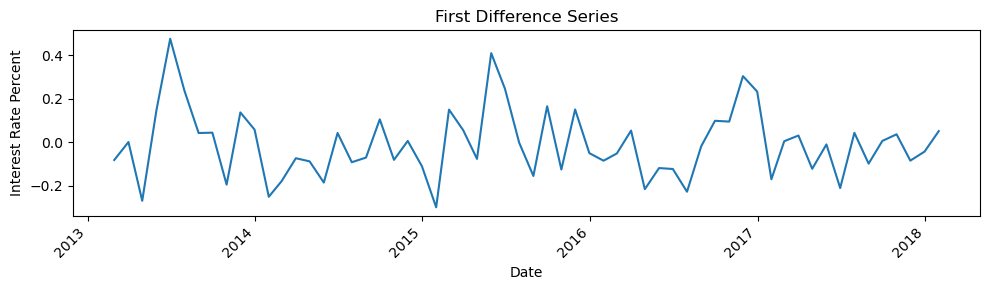

ADF Test for First Difference of Log Series:
  ADF Statistic: -6.3152
  p-value: 0.0000
  Critical Value 1%: -3.5464
  Critical Value 5%: -2.9119
  Critical Value 10%: -2.5937



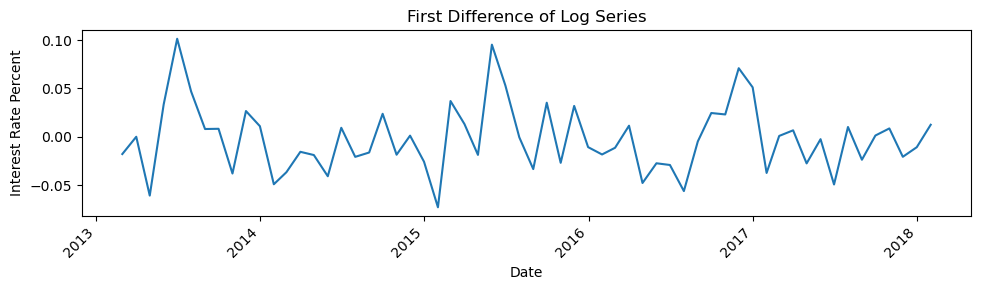

ADF Test for Seasonal Difference (lag 12) Series:
  ADF Statistic: -2.7521
  p-value: 0.0654
  Critical Value 1%: -3.5813
  Critical Value 5%: -2.9268
  Critical Value 10%: -2.6015



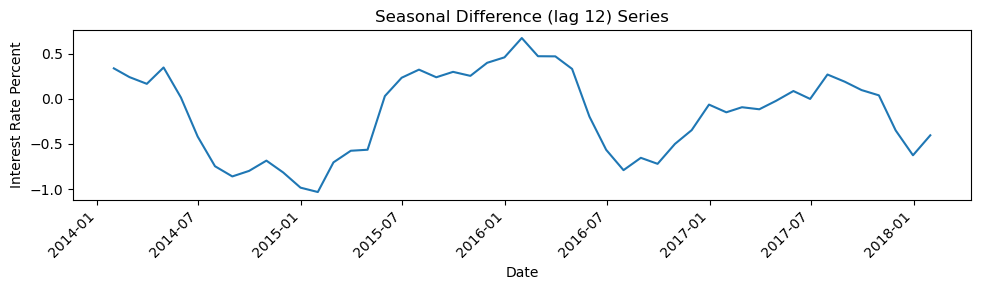

ADF Test for Seasonal Difference of Log Series:
  ADF Statistic: -2.8042
  p-value: 0.0577
  Critical Value 1%: -3.5813
  Critical Value 5%: -2.9268
  Critical Value 10%: -2.6015



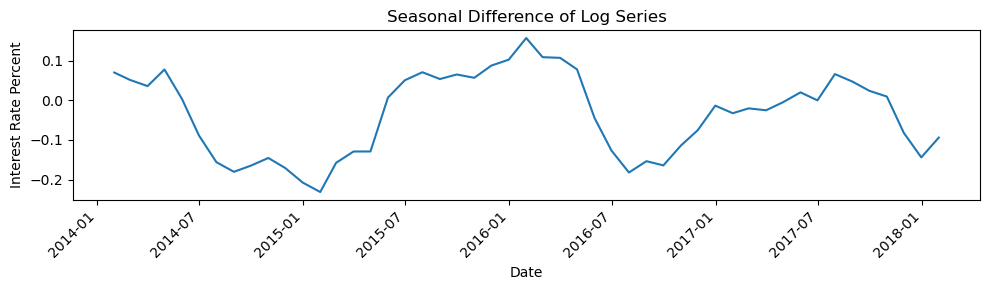

ADF Test for Seasonal Then First Difference Series:
  ADF Statistic: -4.5828
  p-value: 0.0001
  Critical Value 1%: -3.5778
  Critical Value 5%: -2.9253
  Critical Value 10%: -2.6008



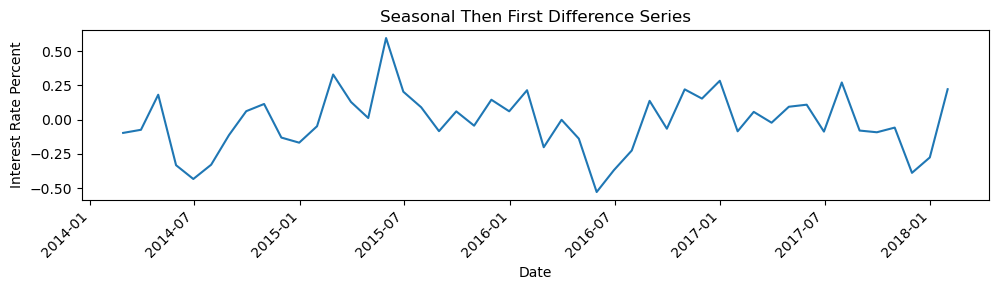

ADF Test for Seasonal Then First Diff of Log Series:
  ADF Statistic: -4.6695
  p-value: 0.0001
  Critical Value 1%: -3.5778
  Critical Value 5%: -2.9253
  Critical Value 10%: -2.6008



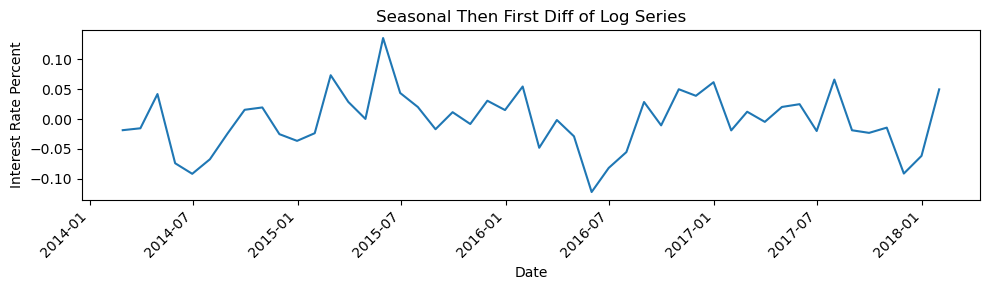

Sample of original and transformed series


Loading ITables v2.4.2 from the internet... (need help?)


In [25]:
date_col = None
for col in df.columns:
    lower = col.lower()
    if 'date' in lower or 'time' in lower:
        date_col = col
        break
if date_col is None:
    date_col = df.columns[0]
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col]).sort_values(by=date_col)

# Identify value column
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if not numeric_cols:
    raise ValueError("Không tìm thấy cột số để phân tích.")
value_col = numeric_cols[0]

# Create monthly series
ts = df.set_index(date_col)[value_col]
ts_monthly = ts.resample('M').mean().interpolate(method='linear')

# Function for stationarity test
def adf_test(series, title="Series"):
    result = adfuller(series.dropna())
    print(f"ADF Test for {title}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    for key, val in result[4].items():
        print(f"  Critical Value {key}: {val:.4f}")
    print()

# Plot helper
def plot_series(series, title="Series"):
    plt.figure(figsize=(10, 3))
    plt.plot(series.index, series.values)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(value_col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 1. Original monthly series
adf_test(ts_monthly, "Original Monthly Series")
plot_series(ts_monthly, "Original Monthly Series")

# 2. Log transform (if all values > 0)
if (ts_monthly > 0).all():
    ts_log = np.log(ts_monthly)
    adf_test(ts_log, "Log Transformed Series")
    plot_series(ts_log, "Log Transformed Series")
else:
    ts_log = None
    print("Series chứa giá trị không dương, bỏ qua log transform.\n")

# 3. First difference
ts_diff = ts_monthly.diff().dropna()
adf_test(ts_diff, "First Difference Series")
plot_series(ts_diff, "First Difference Series")

# 4. If log transform applied, first difference of log (i.e., log returns)
if ts_log is not None:
    ts_log_diff = ts_log.diff().dropna()
    adf_test(ts_log_diff, "First Difference of Log Series")
    plot_series(ts_log_diff, "First Difference of Log Series")

# 5. Seasonal difference (lag 12) on original or log
ts_seasonal_diff = ts_monthly.diff(12).dropna()
adf_test(ts_seasonal_diff, "Seasonal Difference (lag 12) Series")
plot_series(ts_seasonal_diff, "Seasonal Difference (lag 12) Series")

if ts_log is not None:
    ts_log_seasonal_diff = ts_log.diff(12).dropna()
    adf_test(ts_log_seasonal_diff, "Seasonal Difference of Log Series")
    plot_series(ts_log_seasonal_diff, "Seasonal Difference of Log Series")

# 6. Combined difference: seasonal first then first diff
ts_seasonal_then_diff = ts_seasonal_diff.diff().dropna()
adf_test(ts_seasonal_then_diff, "Seasonal Then First Difference Series")
plot_series(ts_seasonal_then_diff, "Seasonal Then First Difference Series")

if ts_log is not None:
    ts_log_seasonal_then_diff = ts_log_seasonal_diff.diff().dropna()
    adf_test(ts_log_seasonal_then_diff, "Seasonal Then First Diff of Log Series")
    plot_series(ts_log_seasonal_then_diff, "Seasonal Then First Diff of Log Series")

# Summary: show first few values of transformed series
import ace_tools_open as tools
summary_df = pd.DataFrame({
    'original': ts_monthly.dropna().iloc[:5],
    'first_diff': ts_diff.iloc[:5]
})
if ts_log is not None:
    summary_df['log'] = ts_log.dropna().iloc[:5]
    summary_df['log_diff'] = ts_log_diff.iloc[:5]
tools.display_dataframe_to_user("Sample of original and transformed series", summary_df)

Kiểm định stationarity sau transform:
ADF Test for Seasonal then First Difference Series: ADF Statistic = -4.6695, p-value = 0.0001
  Critical Value 1%: -3.5778
  Critical Value 5%: -2.9253
  Critical Value 10%: -2.6008



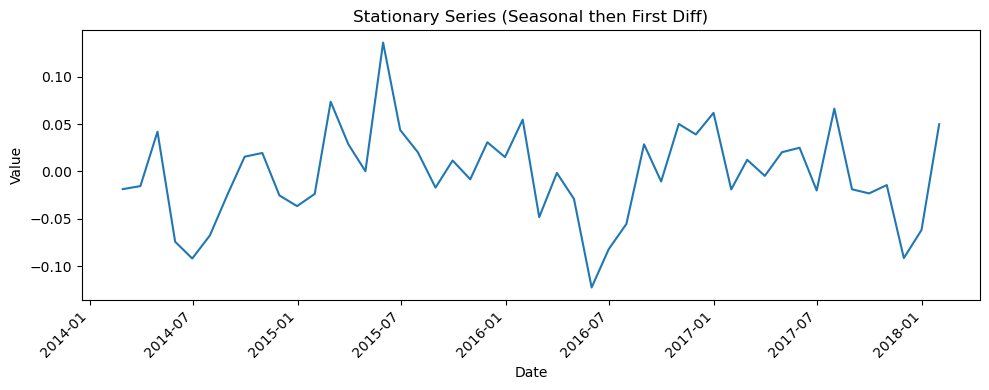

ARCH LM test: LM stat = 9.76, p-value = 0.6370
Không phát hiện ARCH effect: p-value >= 0.05
Không fit ARCH/GARCH vì không phát hiện ARCH effect.


In [29]:
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

ts_seasonal_diff = ts_log.diff(12).dropna()
ts_stationary = ts_seasonal_diff.diff().dropna()

def adf_test(series, title="Series"):
    result = adfuller(series.dropna())
    print(f"ADF Test for {title}: ADF Statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")
    for key, val in result[4].items():
        print(f"  Critical Value {key}: {val:.4f}")
    print()

print("Kiểm định stationarity sau transform:")
adf_test(ts_stationary, "Seasonal then First Difference Series")

# Plot the stationary series
plt.figure(figsize=(10, 4))
plt.plot(ts_stationary.index, ts_stationary.values)
plt.title("Stationary Series (Seasonal then First Diff)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. ARCH test on the stationary series
lm_stat, lm_pvalue, _, _ = het_arch(ts_stationary, nlags=12)
print(f"ARCH LM test: LM stat = {lm_stat:.2f}, p-value = {lm_pvalue:.4f}")
if lm_pvalue < 0.05:
    print("Phát hiện ARCH effect: p-value < 0.05")
else:
    print("Không phát hiện ARCH effect: p-value >= 0.05")

# 4. If ARCH effect detected, fit ARCH/GARCH
if lm_pvalue < 0.05:
    try:
        from arch import arch_model
    except ImportError:
        print("Chưa cài library 'arch'. Vui lòng cài: pip install arch")
    else:
        # Center the series (mean zero) before fitting volatility model
        series_for_garch = ts_stationary - ts_stationary.mean()

        # Fit ARCH(1)
        print("\nFit ARCH(1) model:")
        am_arch1 = arch_model(series_for_garch, mean='Zero', vol='ARCH', p=1, o=0, q=0, dist='t')
        res_arch1 = am_arch1.fit(update_freq=5, disp='off')
        print(res_arch1.summary())

        # Fit GARCH(1,1)
        print("\nFit GARCH(1,1) model:")
        am_garch11 = arch_model(series_for_garch, mean='Zero', vol='GARCH', p=1, o=0, q=1, dist='t')
        res_garch11 = am_garch11.fit(update_freq=5, disp='off')
        print(res_garch11.summary())

        # Compare persistence alpha+beta for GARCH
        if 'alpha[1]' in res_garch11.params and 'beta[1]' in res_garch11.params:
            ab = res_garch11.params['alpha[1]'] + res_garch11.params['beta[1]']
            print(f"Persistence (alpha+beta) for GARCH(1,1): {ab:.4f}")

        # Ljung-Box test on squared standardized residuals
        std_resid = res_garch11.std_resid.dropna()
        lb = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
        print("\nLjung-Box test on squared std residuals (lag=10):")
        display(lb)

        # Forecast volatility for next periods
        horizon = 12
        fc = res_garch11.forecast(horizon=horizon, reindex=False)
        var_fc = fc.variance.iloc[-1]
        last_date = ts_stationary.index[-1]
        # Create future index monthly after last_date
        future_idx = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=horizon, freq='M')
        var_fc.index = future_idx
        vol_fc = np.sqrt(var_fc)

        plt.figure(figsize=(10,4))
        plt.plot(vol_fc.index, vol_fc.values, label='Forecast Volatility (std)')
        plt.title("Forecast Volatility from GARCH(1,1)")
        plt.xlabel("Date")
        plt.ylabel("Std Dev")
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Không fit ARCH/GARCH vì không phát hiện ARCH effect.")

In [32]:
# 7. Grid search SARIMA như trước
ts_clean = ts_monthly.dropna()
p_range = range(0, 4)
d = 1
q_range = range(0, 4)
P_range = range(0, 3)
D = 1
Q_range = range(0, 3)
m = 12

best_aic = np.inf
best_order = None
best_seasonal_order = None

for p in p_range:
    for q in q_range:
        for P in P_range:
            for Q in Q_range:
                try:
                    model = SARIMAX(ts_clean, order=(p, d, q),
                                    seasonal_order=(P, D, Q, m),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False)
                    res = model.fit(disp=False)
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = (p, d, q)
                        best_seasonal_order = (P, D, Q, m)
                except Exception:
                    continue

print(f"Best SARIMA: order={best_order}, seasonal_order={best_seasonal_order}, AIC={best_aic:.1f}")


Best SARIMA: order=(1, 1, 0), seasonal_order=(1, 1, 0, 12), AIC=-24.6


In [33]:
# Fit model kết quả
model_best = SARIMAX(ts_clean, order=best_order,
                     seasonal_order=best_seasonal_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False)
res_best = model_best.fit(disp=False)
print(res_best.summary())

                                     SARIMAX Results                                      
Dep. Variable:              Interest Rate Percent   No. Observations:                   61
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                  15.283
Date:                            Mon, 23 Jun 2025   AIC                            -24.567
Time:                                    15:15:08   BIC                            -19.901
Sample:                                01-31-2013   HQIC                           -22.956
                                     - 01-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2778      0.160      1.731      0.084      -0.037       0.592
ar.S.L12      -0.6160      0.116   

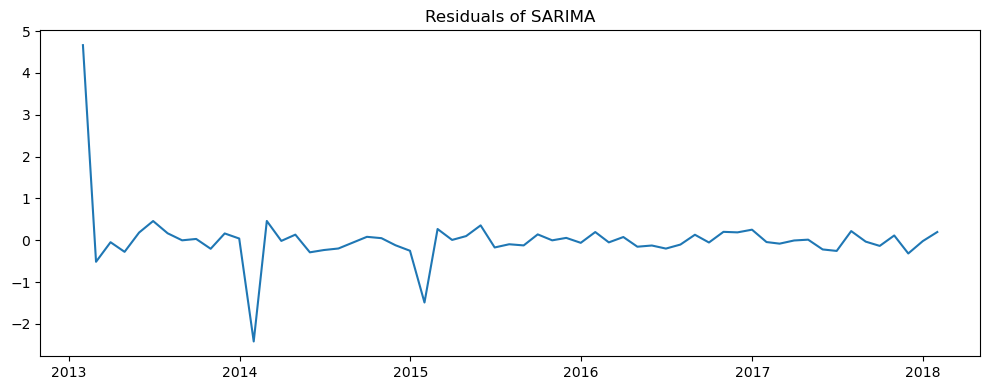

<Figure size 1000x400 with 0 Axes>

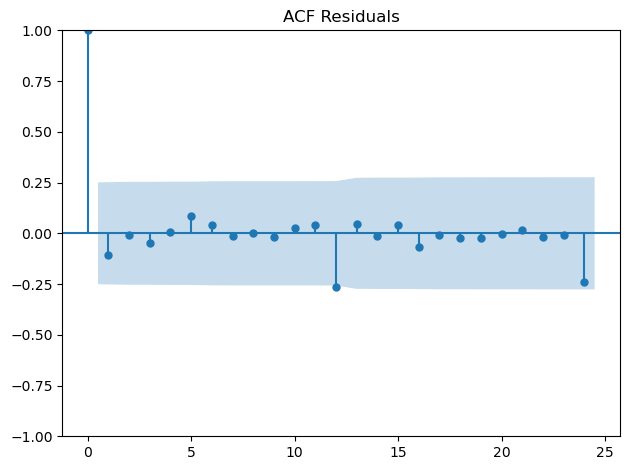

Ljung-Box residuals


Loading ITables v2.4.2 from the internet... (need help?)


In [34]:
# 8. Residual diagnostics
resid = res_best.resid
plt.figure(figsize=(10,4))
plt.plot(resid.index, resid.values)
plt.title("Residuals of SARIMA"); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,4))
plot_acf(resid.dropna(), lags=24)
plt.title("ACF Residuals"); plt.tight_layout(); plt.show()
lb = acorr_ljungbox(resid.dropna(), lags=[10], return_df=True)
tools.display_dataframe_to_user("Ljung-Box residuals", lb)

Train-test MAE: 0.6506, RMSE: 0.7266


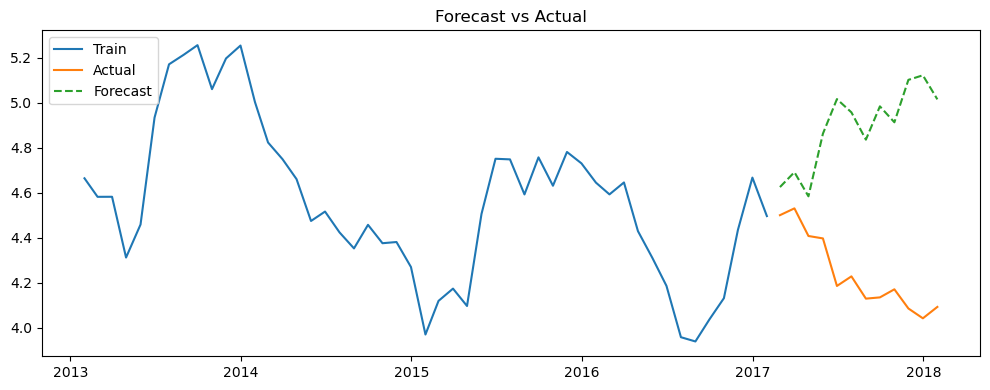

In [35]:
# 9. Train-test và forecast
test_periods = 12
if len(ts_clean) > test_periods:
    train = ts_clean.iloc[:-test_periods]
    test = ts_clean.iloc[-test_periods:]
    res_tt = SARIMAX(train, order=best_order,
                     seasonal_order=best_seasonal_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)
    forecast_tt = res_tt.forecast(steps=test_periods)
    forecast_tt.index = test.index
    mae = mean_absolute_error(test, forecast_tt)
    rmse = np.sqrt(mean_squared_error(test, forecast_tt))
    print(f"Train-test MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    plt.figure(figsize=(10,4))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Actual')
    plt.plot(forecast_tt.index, forecast_tt, label='Forecast', linestyle='--')
    plt.title("Forecast vs Actual"); plt.legend(); plt.tight_layout(); plt.show()


Forecast next 12 months


Loading ITables v2.4.2 from the internet... (need help?)


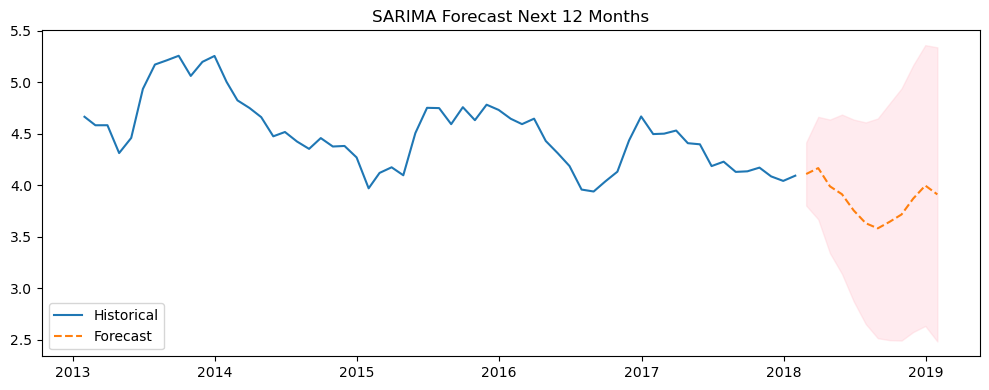

In [36]:
# 10. Forecast future 12 months
future = res_best.get_forecast(steps=12)
forecast_mean = future.predicted_mean
conf_int = future.conf_int()
last_date = ts_clean.index[-1]
future_idx = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=12, freq='M')
forecast_mean.index = future_idx
conf_int.index = future_idx
tools.display_dataframe_to_user("Forecast next 12 months", pd.concat([forecast_mean, conf_int], axis=1))

plt.figure(figsize=(10,4))
plt.plot(ts_clean.index, ts_clean.values, label='Historical')
plt.plot(forecast_mean.index, forecast_mean.values, label='Forecast', linestyle='--')
plt.fill_between(forecast_mean.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title("SARIMA Forecast Next 12 Months")
plt.legend(); plt.tight_layout(); plt.show()